In [36]:
!pip install finrl
!pip install stable-baselines3
!pip install gymnasium
!pip install numpy pandas matplotlib stockstats yfinance
!pip install scikit-learn scipy tensorboard

In [37]:
!pip install gym

In [38]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.logger import configure
import os



In [39]:
class StockDataIterator:
    def __init__(self, file_path, lookback_window=10, chunk_size=100000):
        self.file_path = file_path
        self.lookback_window = lookback_window
        self.chunk_size = chunk_size
        self.chunk_reader = pd.read_csv(
            self.file_path,
            usecols=['date', 'tic', 'close', 'high', 'low'],  # Drop unnecessary columns
            dtype={'close': 'float32', 'high': 'float32', 'low': 'float32', 'tic': 'category'},
            parse_dates=['date'],
            chunksize=self.chunk_size
        )
        self.data_buffer = pd.DataFrame()
        self.dates_cache = np.array([])  # Cache unique dates for efficiency

    def __iter__(self):
        self.data_buffer = pd.DataFrame()
        self.dates_cache = np.array([])
        return self

    def __next__(self):
        """Loads and processes stock data in chunks"""
        while True:
            # Load more data if needed
            while self.data_buffer.empty or len(self.dates_cache) < self.lookback_window + 2:
                try:
                    chunk = next(self.chunk_reader)
                    chunk.sort_values(['date', 'tic'], inplace=True)  # Sort once per chunk
                    self.data_buffer = pd.concat([self.data_buffer, chunk], ignore_index=True)
                    self.dates_cache = self.data_buffer['date'].unique()
                except StopIteration:
                    if len(self.dates_cache) < self.lookback_window:
                        raise StopIteration

            # Select lookback window
            window_dates = self.dates_cache[:self.lookback_window]
            valid_mask = self.data_buffer['date'].isin(window_dates)

            # Ensure all tickers have complete lookback data
            tic_counts = self.data_buffer[valid_mask].groupby('tic').size()
            valid_tics = tic_counts[tic_counts == self.lookback_window].index

            if not valid_tics.empty:
                filtered_data = self.data_buffer[valid_mask & self.data_buffer['tic'].isin(valid_tics)]
                prepared = self._prepare_features(filtered_data)

                if prepared:
                    self.dates_cache = self.dates_cache[1:]  # Drop oldest date
                    self.data_buffer = self.data_buffer[~self.data_buffer['date'].isin([window_dates[0]])]
                    return prepared

            # Drop oldest date and continue
            self.dates_cache = self.dates_cache[1:]
            self.data_buffer = self.data_buffer[~self.data_buffer['date'].isin([window_dates[0]])]

    def _prepare_features(self, window_data):
        """Optimized feature calculation"""
        if window_data.empty:
            return []

        features = []
        grouped = window_data.groupby('tic', observed=False)

        for tic, group in grouped:
            close = group['close'].values
            high = group['high'].values
            low = group['low'].values

            # Check if 'close' is empty to prevent IndexError
            if len(close) > 0:
                features.append({
                    'tic': tic,
                    'close_prices': close.astype('float32'),
                    'returns': np.diff(close, prepend=close[0]) / close[0],
                    'log_returns': np.log(close / np.roll(close, 1)),
                    'price_range': (high - low) / close
                })
            else:
                # Handle empty 'close' case (e.g., skip or add a placeholder)
                print(f"Warning: No data for {tic} in the current window. Skipping...")

        return features



In [40]:
import gym
from gym import spaces
import numpy as np

import gym
import numpy as np
from gym import spaces

class StockTradingEnv(gym.Env):
    def __init__(self, data_iterator):
        super(StockTradingEnv, self).__init__()

        self.data_iterator = data_iterator
        self.initial_cash = 10000.0
        self.transaction_cost = 0.001
        self.lookback_window = data_iterator.lookback_window
        num_features = 4  # close_prices, returns, log_returns, price_range

        # Define observation space: Flattened representation
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.lookback_window * num_features,), dtype=np.float32
        )

        # Define action space: Buy (0), Hold (1), Sell (2), Short Sell (3), Buy to Cover (4)
        self.action_space = spaces.Discrete(5)

        self.iterator = iter(self.data_iterator)
        self.reset()

    def _get_observation(self):
        """Returns the current state as a flattened observation."""
        if self.current_features is None:
            return np.zeros(self.observation_space.shape, dtype=np.float32)

        features = self.current_features[0]
        return np.concatenate([
            features['close_prices'],
            features['returns'],
            features['log_returns'],
            features['price_range']
        ]).astype(np.float32)

    def reset(self):
        """Resets the environment for a new episode."""
        self.cash = self.initial_cash
        self.stock_held = 0
        self.iterator = iter(self.data_iterator)  # Reset data iterator

        try:
            self.current_features = next(self.iterator)
        except StopIteration:
            self.current_features = None
            return np.zeros(self.observation_space.shape, dtype=np.float32), {}

        return self._get_observation(), {}

    def step(self, action):
        """Executes the chosen action and returns the next state, reward, and done flag."""
        if self.current_features is None:
            return self._get_observation(), 0, True, {}

        current_price = self.current_features[0]['close_prices'][-1]
        prev_portfolio_value = self.cash + self.stock_held * current_price

        # Execute action
        if action == 0 and self.cash >= current_price:  # Buy
            self.stock_held += 1
            self.cash -= current_price
        elif action == 1:  # Hold (no action taken)
            pass
        elif action == 2 and self.stock_held > 0:  # Sell
            self.stock_held -= 1
            self.cash += current_price
        elif action == 3:  # Short Sell
            self.stock_held -= 1
            self.cash += current_price
        elif action == 4 and self.stock_held < 0:  # Buy to Cover
            self.stock_held += 1
            self.cash -= current_price

        # Reward calculation (percentage return)
        try:
            self.current_features = next(self.iterator)
            new_price = self.current_features[0]['close_prices'][-1]
        except StopIteration:
            return self._get_observation(), 0, True, {}

        current_portfolio_value = self.cash + self.stock_held * new_price
        reward = (current_portfolio_value - prev_portfolio_value) / prev_portfolio_value

        # Apply transaction cost for non-hold actions
        if action != 1:
            reward -= self.transaction_cost

        return self._get_observation(), reward, False, {
            "cash": self.cash,
            "stock_held": self.stock_held,
            "current_price": new_price,
            "portfolio_value": current_portfolio_value
        }

    def render(self):
        """Prints the current portfolio status."""
        if self.current_features:
            current_price = self.current_features[0]['close_prices'][-1]
            portfolio_value = self.cash + self.stock_held * current_price
            print(f"Cash: {self.cash:.2f}, Stocks: {self.stock_held}, "
                  f"Price: {current_price:.2f}, Portfolio: {portfolio_value:.2f}")


In [41]:
if __name__ == "__main__":
    data_iterator = StockDataIterator(
        file_path="/content/historical_data.csv",
        lookback_window=1,  # Reduced lookback window
        chunk_size=50       # Lower chunk size
    )

    env = StockTradingEnv(data_iterator=data_iterator)

    obs = env.reset()
    max_steps = 50  # Limit steps
    done = False
    total_reward = 0
    step_count = 0

    while not done and step_count < max_steps:
        action = env.action_space.sample()
        obs, reward, done, _ = env.step(action)
        total_reward += reward
        step_count += 1
        # env.render()  # Disable rendering for speed

    print(f"Total reward: {total_reward}")


Total reward: -0.03801477744652486


In [42]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback
import matplotlib.pyplot as plt

# Stock Data Iterator with optimized chunking
class StockDataIterator:
    def __init__(self, file_path, lookback_window, chunk_size):
        self.data = pd.read_csv(file_path)
        self.lookback_window = lookback_window
        self.chunk_size = chunk_size
        self.current_index = 0

    def next_batch(self):
        start = self.current_index
        end = min(self.current_index + self.chunk_size, len(self.data))
        batch = self.data[start:end]
        self.current_index = end
        return batch

# Add technical indicators without TA-Lib
def add_indicators(data):
    # Simple Moving Average (SMA)
    data['SMA'] = data['close'].rolling(window=10).mean()

    # Relative Strength Index (RSI)
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    short_ema = data['close'].ewm(span=12, adjust=False).mean()
    long_ema = data['close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = short_ema - long_ema

    # Bollinger Bands
    std_dev = data['close'].rolling(window=10).std()
    data['Upper_BB'] = data['SMA'] + (2 * std_dev)
    data['Lower_BB'] = data['SMA'] - (2 * std_dev)

    return data

# Stock Trading Environment
class StockTradingEnv(gym.Env):
    def __init__(self, data_iterator):
        super(StockTradingEnv, self).__init__()
        self.data_iterator = data_iterator
        self.current_step = 0
        self.current_data = self.data_iterator.next_batch()
        self.stock_held = 0
        self.cash = 10000
        self.transaction_cost = 0.001

        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(self.data_iterator.lookback_window, 5), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.current_data = self.data_iterator.next_batch()
        self.stock_held = 0
        self.cash = 10000
        return self._get_observation()

    def step(self, action):
        current_price = self.current_data.iloc[self.current_step]["close"]
        prev_portfolio_value = self.cash + self.stock_held * current_price

        if action == 0 and self.cash >= current_price:  # Buy
            self.stock_held += 1
            self.cash -= current_price
        elif action == 2 and self.stock_held > 0:  # Sell
            self.stock_held -= 1
            self.cash += current_price
        elif action == 3:  # Short Sell
            self.stock_held -= 1
            self.cash += current_price
        elif action == 4 and self.stock_held < 0:  # Buy to Cover
            self.stock_held += 1
            self.cash -= current_price

        reward = self.custom_reward(action, current_price, prev_portfolio_value)

        self.current_step += 1
        done = self.current_step >= len(self.current_data) - 1

        return self._get_observation(), reward, done, {}

    def _get_observation(self):
        start_idx = max(0, self.current_step - self.data_iterator.lookback_window)
        end_idx = self.current_step

        obs = self.current_data.iloc[start_idx:end_idx].iloc[:, 1:6].values

        # Ensure the observation has the correct shape (lookback_window, 5)
        if obs.shape[0] < self.data_iterator.lookback_window:
            padding = np.zeros((self.data_iterator.lookback_window - obs.shape[0], obs.shape[1]))
            obs = np.vstack([padding, obs])  # Pad with zeros if needed

        return obs

    def custom_reward(self, action, current_price, prev_portfolio_value):
        current_portfolio_value = self.cash + self.stock_held * current_price
        reward = (current_portfolio_value - prev_portfolio_value) / prev_portfolio_value
        if action != 1:
            reward -= self.transaction_cost
        return reward

# Create Data Iterator
data_iterator = StockDataIterator(
    file_path="/content/historical_data.csv",
    lookback_window=5,
    chunk_size=5000
)
data_iterator.data = add_indicators(data_iterator.data)

# Create and wrap the environment using DummyVecEnv
def make_env():
    return StockTradingEnv(data_iterator=data_iterator)

env = DummyVecEnv([make_env] * 4)

# PPO model with optimized hyperparameters
policy_kwargs = dict(
    net_arch=dict(
        pi=[64, 64],
        vf=[64, 64]
    )
)

model = PPO(
    "MlpPolicy",
    env,
    policy_kwargs=policy_kwargs,
    learning_rate=0.0003,
    n_steps=512,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    verbose=1
)

# Train the model with reduced timesteps
checkpoint_callback = CheckpointCallback(save_freq=500, save_path='./models/', name_prefix='ppo_model')

try:
    model.learn(total_timesteps=10000)
    model.save("ppo_stock_trading_model")
    print("Training completed successfully!")
except Exception as e:
    print(f"Error during training: {str(e)}")

# Evaluation
def evaluate_model(model, env, num_episodes=3):
    total_rewards = []
    for _ in range(num_episodes):
        obs = env.reset()
        done = [False] * env.num_envs  # Initialize done as a list of False values
        total_reward = 0
        while not all(done):  # Continue while any environment is not done
            action, _states = model.predict(obs)
            obs, reward, done, _ = env.step(action)
            total_reward += reward[0]  # Accumulate reward from the first environment
        total_rewards.append(total_reward)

    avg_reward = np.mean(total_rewards)
    print(f"Average Reward over {num_episodes} episodes: {avg_reward}")
evaluate_model(model, env)



/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 543  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 535          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0096920375 |
|    clip_fraction        | 0.0492       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.6         |
|    explained_variance   | -36          |
|    learning_rate        | 0.0003       |
|    loss                 | -0.00318     |
|    n_updates            | 5            |
|    policy_gradient_loss | -0.00858     |
|    value_loss           | 0.0462       |
------------------------------------------

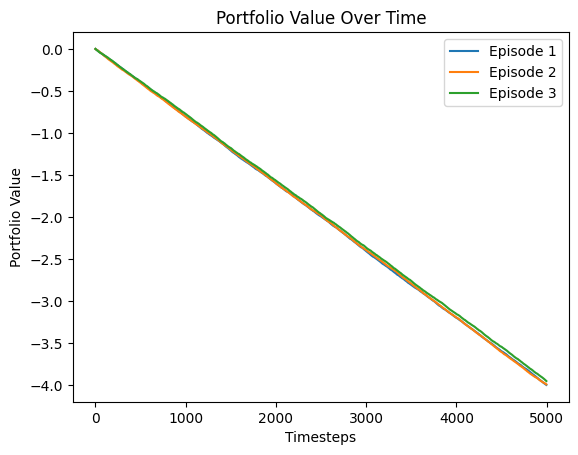

In [43]:
def plot_portfolio_value(model, env, num_episodes=3):
    for episode in range(num_episodes):
        obs = env.reset()
        done = [False] * env.num_envs  # Initialize done as a list of False values
        portfolio_values = []  # Store portfolio values over time
        total_reward = 0

        while not all(done):  # Check if all environments are done
            action, _states = model.predict(obs)
            obs, reward, done, _ = env.step(action)
            total_reward += reward[0]  # Take first env's reward
            portfolio_values.append(total_reward)

        # Plot for each episode
        plt.plot(portfolio_values, label=f'Episode {episode+1}')

    plt.xlabel('Timesteps')
    plt.ylabel('Portfolio Value')
    plt.title('Portfolio Value Over Time')
    plt.legend()
    plt.show()

# Run the function
plot_portfolio_value(model, env)


In [48]:
import numpy as np
import pandas as pd
import os
import itertools
import time
from tqdm import tqdm
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv

def hyperparameter_tuning(
    data_path,
    base_model_path="tuning_models",
    max_stocks_options=[50, 100],
    lookback_options=[15, 30, 45],
    learning_rate_options=[1e-4, 3e-4, 1e-3],
    gamma_options=[0.95, 0.99],
    ent_coef_options=[0.01, 0.005],
    n_steps_options=[512, 1024],
    batch_size_options=[64, 128],
    transaction_cost_options=[0.001, 0.002],
    n_epochs_options=[5, 10],
    timesteps=100000,
    eval_episodes=3,
    n_eval_envs=2
):
    """
    Perform hyperparameter tuning for the portfolio optimization model.
    """
    if not os.path.exists(base_model_path):
        os.makedirs(base_model_path)

    param_combinations = list(itertools.product(
        max_stocks_options, lookback_options, learning_rate_options,
        gamma_options, ent_coef_options, n_steps_options, batch_size_options,
        transaction_cost_options, n_epochs_options
    ))

    results = []

    for idx, params in enumerate(tqdm(param_combinations, desc="Hyperparameter Tuning")):
        max_stocks, lookback, learning_rate, gamma, ent_coef, n_steps, batch_size, transaction_cost, n_epochs = params
        model_name = f"model_{idx}_ms{max_stocks}_lb{lookback}_lr{learning_rate}_g{gamma}_e{ent_coef}"
        model_path = os.path.join(base_model_path, model_name)

        env = DummyVecEnv([lambda: StockPortfolioIterator(data_path, max_stocks, lookback, transaction_cost)])
        model = PPO("MlpPolicy", env, learning_rate=learning_rate, gamma=gamma, ent_coef=ent_coef,
                    n_steps=n_steps, batch_size=batch_size, n_epochs=n_epochs, verbose=0)

        eval_callback = EvalCallback(env, best_model_save_path=model_path, log_path=model_path,
                                     eval_freq=timesteps//10, n_eval_episodes=eval_episodes)

        try:
            model.learn(total_timesteps=timesteps, callback=eval_callback)
            results.append((model_name, "Success"))
        except Exception as e:
            results.append((model_name, f"Failed: {str(e)}"))

    results_df = pd.DataFrame(results, columns=["Model", "Status"])
    results_df.to_csv(os.path.join(base_model_path, "tuning_results.csv"), index=False)
    print("Hyperparameter tuning completed.")
